In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Visualization settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)


In [4]:
# Load Dataset

df = pd.read_csv("customers.csv")

# Select numerical features only
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns
X = df[numerical_columns]

print("Numerical Features Used:")
print(numerical_columns.tolist())


Numerical Features Used:
['id', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'view', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']


In [5]:
# 3. Feature Scaling (CRUCIAL)
# ----------------------------
# KMeans is distance-based → scaling is mandatory
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

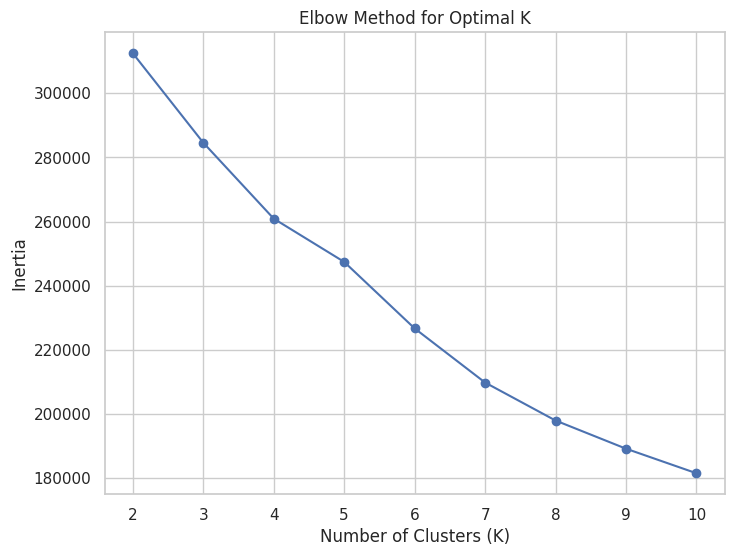

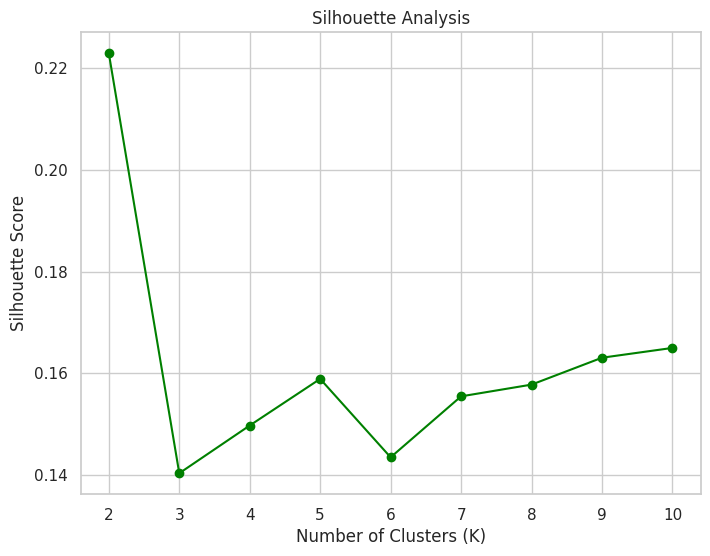

In [6]:
# 4. Find Optimal K (Elbow + Silhouette)
# ----------------------------
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# ---- Elbow Method ----
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

# ---- Silhouette Score ----
plt.plot(K_range, silhouette_scores, marker="o", color="green")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

In [7]:
# 5. Apply Final KMeans Model
# ----------------------------
optimal_k = 3  # chosen based on elbow + silhouette

kmeans = KMeans(
    n_clusters=optimal_k,
    init="k-means++",
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print("\nCluster Distribution:")
print(df["Cluster"].value_counts())



Cluster Distribution:
Cluster
1    9211
0    8644
2    3758
Name: count, dtype: int64


In [8]:
# 6. Apply PCA for Visualization
# ----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\nPCA Explained Variance Ratio:")
print(pca.explained_variance_ratio_)
print("Total Variance Captured:", np.sum(pca.explained_variance_ratio_))

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]



PCA Explained Variance Ratio:
[0.31311132 0.12770148]
Total Variance Captured: 0.4408127987911002


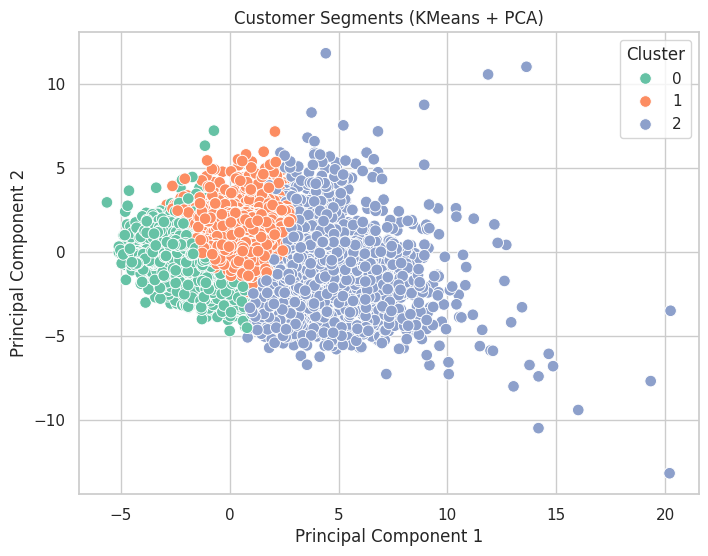

In [9]:
# 7. PCA Cluster Visualization
# ----------------------------
sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set2",
    s=70
)

plt.title("Customer Segments (KMeans + PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

In [10]:
# 8. Cluster Interpretation
# ----------------------------
cluster_summary = df.groupby("Cluster")[numerical_columns].mean()

print("\nCluster-wise Feature Means:")
print(cluster_summary)


Cluster-wise Feature Means:
                   id         price  bedrooms  bathrooms  sqft_living  \
Cluster                                                                 
0        4.467339e+09  4.200724e+05  2.976053   1.507375  1503.605044   
1        4.783834e+09  4.469761e+05  3.442297   2.320676  2035.549235   
2        4.341267e+09  1.044365e+06  4.103779   3.007118  3514.174295   

             sqft_lot    floors      view     grade   sqft_above  \
Cluster                                                            
0         8988.454072  1.175324  0.164044  6.871124  1225.714947   
1        13598.176528  1.650527  0.062317  7.694496  1816.211052   
2        32878.629324  1.845130  0.817456  9.372006  3014.445982   

         sqft_basement     yr_built  yr_renovated       zipcode        lat  \
Cluster                                                                      
0           277.890097  1946.875405    119.244331  98111.267353  47.588580   
1           219.338183  1988.0

In [11]:
# 9. Save Results
# ----------------------------
df.to_csv("week18_clustered_output.csv", index=False)
print("\nClustered dataset saved successfully!")


Clustered dataset saved successfully!
